The idea of this notebook is explore the realtionship of the behavioral features v/s risk of lung cancer

In [2]:
import pandas as pd
df_lung = pd.read_csv('data/lung_cancer.csv')

In [3]:
df_variables_desc = pd.read_json('data/variables_descriptions.json')
print(df_variables_desc)
behavior_features = [
    'age', # Age of the individual in years
    'gender', # Biological sex (0 = Female, 1 = Male)
    'education_years', # Total years of formal education completed
    'income_level', # Socioeconomic status on an ordinal scale (1 = lowest, 5 = highest)
    'smoker', # Indicates whether the individual has a history of smoking (0 = No, 1 = Yes)
    'smoking_years', # Total number of years the individual has smoked
    'cigarettes_per_day', # Average number of cigarettes smoked per day
    'pack_years', # Cumulative smoking exposure combining duration and intensity
    'passive_smoking', # Exposure to secondhand smoke (0 = No, 1 = Yes)
    'air_pollution_index', # Air quality index representing long-term pollution exposure
    'occupational_exposure', # Exposure to hazardous substances at work (0 = No, 1 = Yes)
    'radon_exposure', # History of radon exposure (0 = No, 1 = Yes)
    'family_history_cancer', # Family history of cancer (0 = No, 1 = Yes)
    'asthma', # History of asthma (0 = No, 1 = Yes)
    'previous_tb', # History of tuberculosis infection (0 = No, 1 = Yes)
    'chronic_cough', # Presence of long-term cough symptoms (0 = No, 1 = Yes)
    'chest_pain', # Reports of chest pain (0 = No, 1 = Yes)
    'shortness_of_breath', # Presence of breathing difficulty (0 = No, 1 = Yes)
    'fatigue', # Persistent fatigue symptoms (0 = No, 1 = Yes)
    'bmi', # Body mass index category value
    'exercise_hours_per_week', # Average weekly physical activity duration
    'diet_quality', # Overall dietary quality score (1 = poor, 5 = excellent)
    'alcohol_units_per_week', # Average alcohol consumption per week
    'healthcare_access' # Access to healthcare services (1 = poor, 5 = excellent)
]

                       name                                        description
0                       age                     Age of the individual in years
1                    gender              Biological sex (0 = Female, 1 = Male)
2           education_years          Total years of formal education completed
3              income_level  Socioeconomic status on an ordinal scale (1 = ...
4                    smoker  Indicates whether the individual has a history...
5             smoking_years    Total number of years the individual has smoked
6        cigarettes_per_day        Average number of cigarettes smoked per day
7                pack_years  Cumulative smoking exposure combining duration...
8           passive_smoking     Exposure to secondhand smoke (0 = No, 1 = Yes)
9       air_pollution_index  Air quality index representing long-term pollu...
10    occupational_exposure  Exposure to hazardous substances at work (0 = ...
11           radon_exposure        History of radon 

Multicollinearity
There are some redundant variables, per example

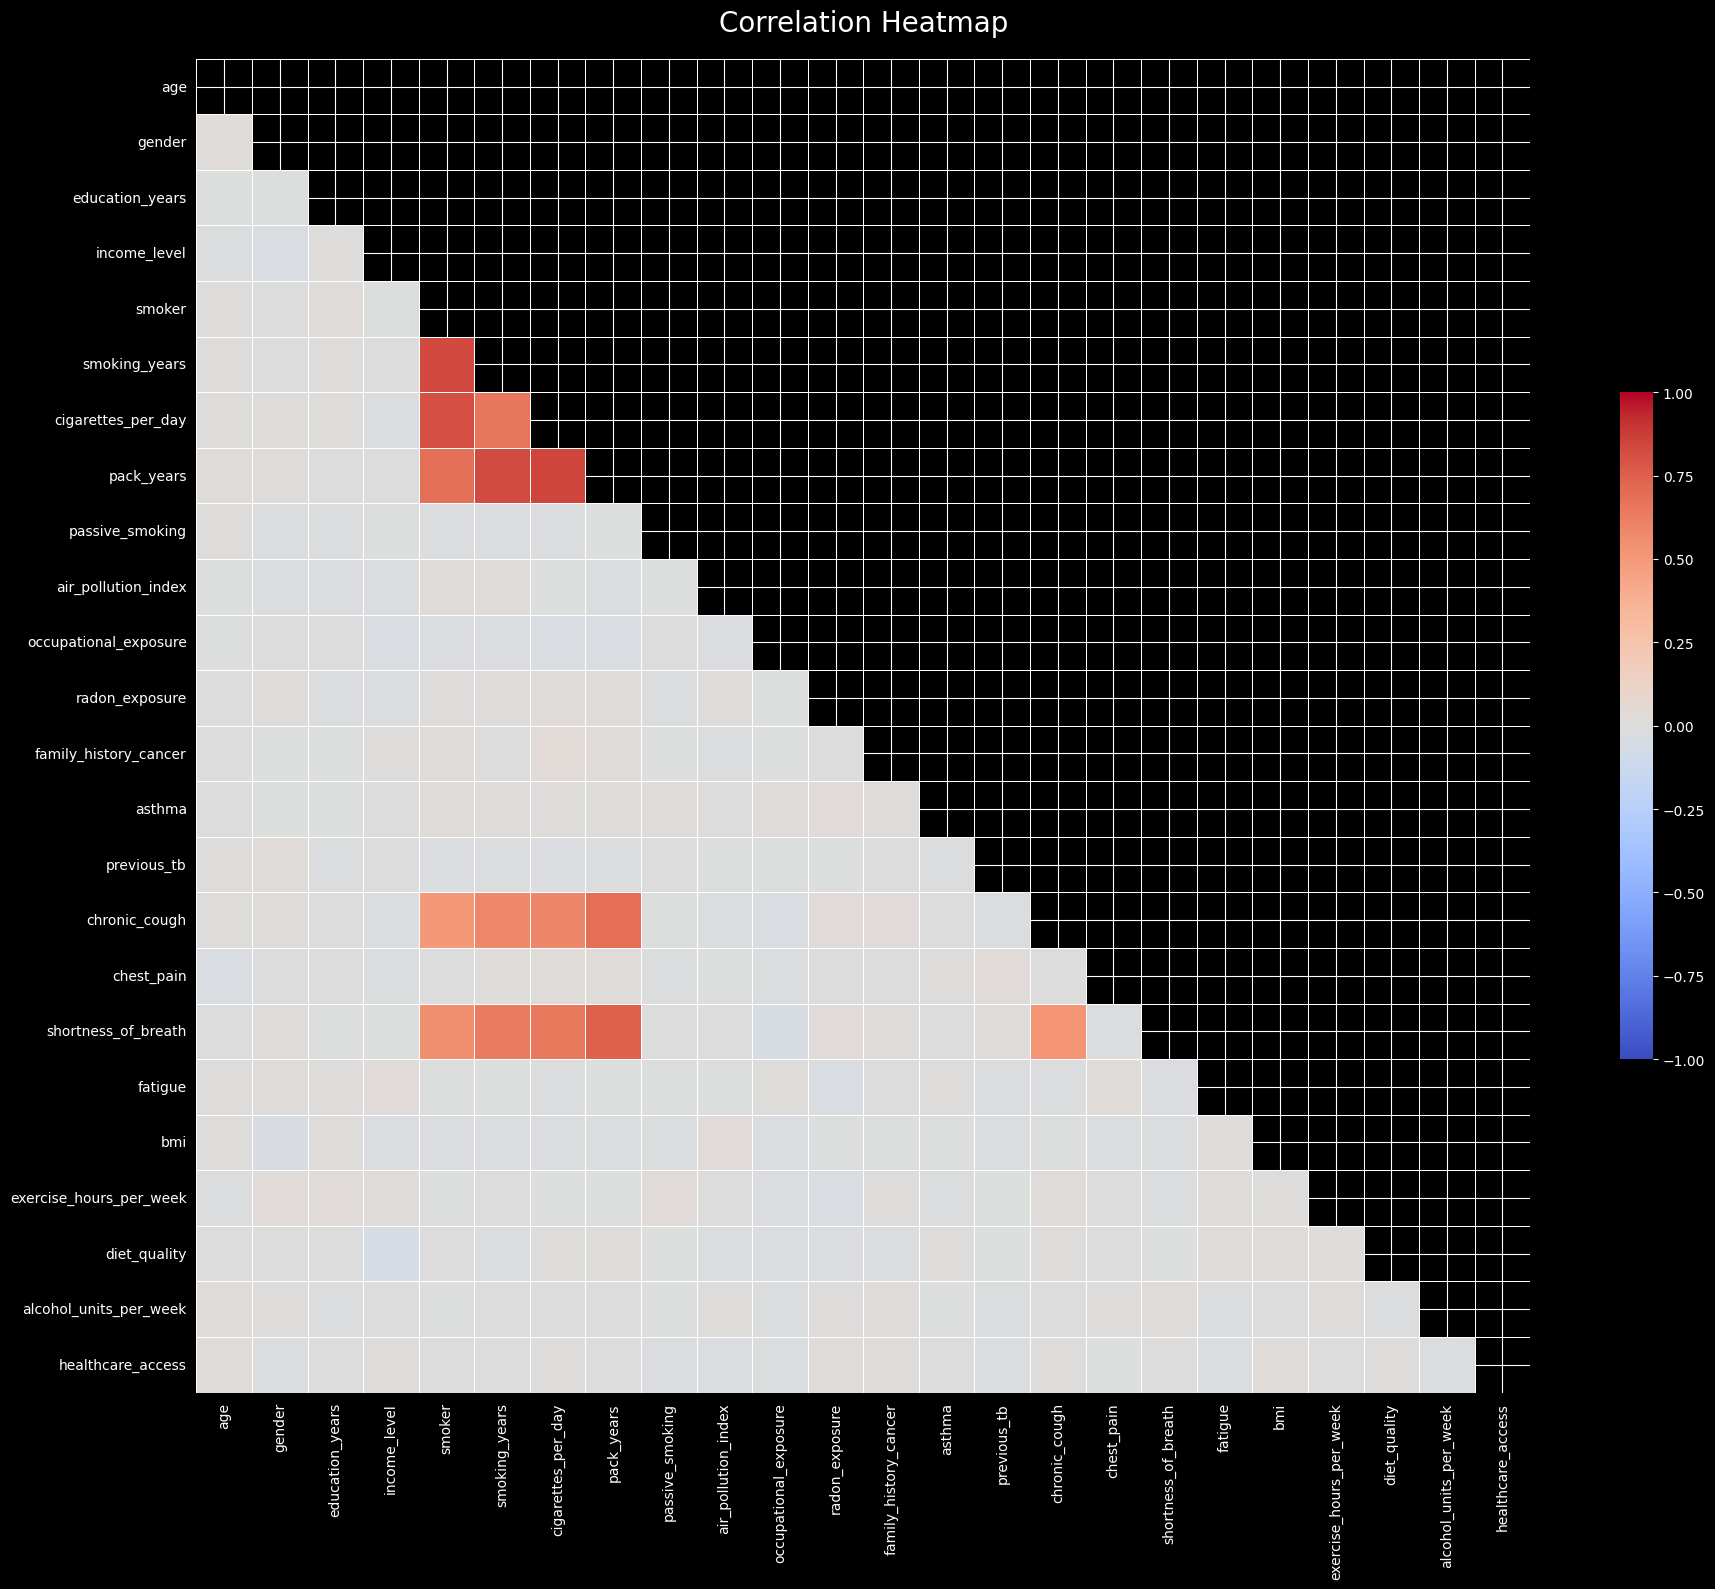

In [4]:
from statsmodels_utils import plot_correlation_heatmap
plot_correlation_heatmap(df_lung[behavior_features], title='Correlation Heatmap')

In [5]:
from statsmodels_utils import drop_highly_correlated_pairs
target_label = 'lung_cancer_risk'
X_clean = drop_highly_correlated_pairs(df_lung.drop([target_label], axis=1), df_lung[target_label])

Hunting for pairs with correlation > 0.8...
Tie-breaker: Kept 'smoking_years', Dropped 'smoker'
Tie-breaker: Kept 'pack_years', Dropped 'smoking_years'
Tie-breaker: Kept 'pack_years', Dropped 'cigarettes_per_day'
Tie-breaker: Kept 'pack_years', Dropped 'oxygen_saturation'
Tie-breaker: Kept 'pack_years', Dropped 'fev1_x10'
Tie-breaker: Kept 'pack_years', Dropped 'crp_level'
----------------------------------------
Dropped 6 variables due to pairwise correlation.


In [7]:
from statsmodels_utils import calculate_and_drop_vif
X_clean_vif_dropped = calculate_and_drop_vif(X_clean, verbose=True)
print('',*X_clean.columns)

Starting VIF Multicollinearity Check...

----------------------------------------

[DROPPED] 'pack_years'
  * VIF Score: 5.05 (Overlap: 80.2%)
  * Primary Suspects (Highest pairwise correlations with this feature):
      - xray_abnormal (0.75)
      - shortness_of_breath (0.74)
      - chronic_cough (0.69)
  * Current Runner-Ups (Watch these scores drop in the next loop!):
      - xray_abnormal: 2.30
      - shortness_of_breath: 2.26
      - chronic_cough: 1.91
------------------------------
----------------------------------------
VIF Check Complete!
Features dropped: 1
 age gender education_years income_level pack_years passive_smoking air_pollution_index occupational_exposure radon_exposure family_history_cancer copd asthma previous_tb chronic_cough chest_pain shortness_of_breath fatigue bmi xray_abnormal exercise_hours_per_week diet_quality alcohol_units_per_week healthcare_access


In [8]:
X_clean2_dropped_vif , features_dropped= calculate_and_drop_vif(df_lung.drop([target_label], axis=1), verbose=True)
x_clean2_dropped_pair = drop_highly_correlated_pairs(X_clean2_dropped_vif, df_lung[target_label])
print('',*X_clean2_dropped_vif.columns)

Starting VIF Multicollinearity Check...

----------------------------------------

[DROPPED] 'pack_years'
  * VIF Score: 35.16 (Overlap: 97.2%)
  * Primary Suspects (Highest pairwise correlations with this feature):
      - fev1_x10 (0.94)
      - crp_level (0.92)
      - oxygen_saturation (0.90)
  * Current Runner-Ups (Watch these scores drop in the next loop!):
      - cigarettes_per_day: 14.15
      - smoking_years: 13.62
      - smoker: 12.75
------------------------------

[DROPPED] 'smoker'
  * VIF Score: 10.29 (Overlap: 90.3%)
  * Primary Suspects (Highest pairwise correlations with this feature):
      - smoking_years (0.83)
      - cigarettes_per_day (0.81)
      - fev1_x10 (0.63)
  * Current Runner-Ups (Watch these scores drop in the next loop!):
      - cigarettes_per_day: 10.17
      - smoking_years: 9.95
      - fev1_x10: 7.08
------------------------------

[DROPPED] 'fev1_x10'
  * VIF Score: 6.35 (Overlap: 84.2%)
  * Primary Suspects (Highest pairwise correlations with t

In [9]:
print(set(X_clean2_dropped_vif.columns).difference(X_clean.columns))
print(set(X_clean.columns).difference(X_clean2_dropped_vif.columns))


{'crp_level', 'smoking_years', 'cigarettes_per_day', 'oxygen_saturation'}
{'pack_years'}
